In [ ]:
# Código 2.1: ler o arquivo "dirtyshop.xlsx" excel
import pandas as pd
df = pd.read_excel('/content/sample_data/dirtyshop.xlsx')
print(df.head())

#  mostra os tipos de variáveis do arquivo dirtyshop
print(df.info())

#  muda o tipo da variável FONE para object
df['FONE'] = df['FONE'].astype(object)
print(df.info())




In [ ]:
#Código 2.2. - Análise exploratória de dados
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('/content/sample_data/dirtyshop.xlsx')

# cria uma tabela de frequência da variável UNIFED
frequency_table = df['UNIFED'].value_counts()
print(frequency_table)

# faz tabela com proporções
proportion_table = df['UNIFED'].value_counts(normalize=True)
print(proportion_table)

# Cria o gráfico de barras
plt.figure(figsize=(10, 6)) # Ajusta o tamanho da figura
sns.barplot(x=frequency_table.index, y=frequency_table.values)
plt.xlabel('UNIFED')
plt.ylabel('Frequência')
plt.title('Frequência de UNIFED')
plt.show()

# corrige valores errados da variável UNIFED
df['UNIFED'] = df['UNIFED'].replace({'S.P.': 'SP', 'BH': 'MG'})

#  cria uma tabela de frequência da variável RESID
frequency_table = df['RESID'].value_counts()
print(frequency_table)

# substitui erro de digitação da variável RESID
df['RESID'] = df['RESID'].replace({'pROP': 'PROP'})
frequency_table = df['RESID'].value_counts()
print(frequency_table)

# mostra tabela de frequência da variável RST
frequency_table = df['RST'].value_counts()
print(frequency_table)

#  substitui o valor 2 na variável RST por missing value

df['RST'] = df['RST'].replace(2, pd.NA)
frequency_table = df['RST'].value_counts()
print(frequency_table)

# Calcula estatísticas descritivas para a variável RNDTOT (média, desvio padrão, mínimo, máximo, quartis)
print(df['RNDTOT'].describe())

# variância da variável RNDTOT
print("Variância da variável RNDTOT:", df['RNDTOT'].var())

# desvio mediano absoluto da variável RNDTOT

mad_value = (df['RNDTOT'] - df['RNDTOT'].median()).abs().median()
print("Desvio Mediano Absoluto da variável RNDTOT:", mad_value)

# Gera o histograma da variável RNDTOT
plt.figure(figsize=(10, 6)) # Ajusta o tamanho da figura
sns.histplot(df['RNDTOT']) # Gera o histograma ; esta função é do pacote seaborn (sns)
plt.xlabel('RNDTOT')
plt.ylabel('Frequência')
plt.title('Histograma de RNDTOT')
plt.show()

# Gera o box-plot da variável RNDTOT
plt.figure(figsize=(10, 6)) # Ajusta o tamanho da figura
sns.boxplot(y=df['RNDTOT']) # Gera o box-plot da variável RNDTOT
plt.ylabel('RNDTOT')
plt.title('Box-plot de RNDTOT')
plt.show()

# calcula o coeficiente de assimetria da variável
print("Coeficiente de Assimetria da variável RNDTOT:", df['RNDTOT'].skew())

In [ ]:
#Código 2.2.3. - Cruzamento de variáveis (análise bivariada)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.gridspec import GridSpec


df = pd.read_excel('/content/sample_data/dirtyshop.xlsx')

# Criando a tabela cruzada entre RESID e STATUS
cross_tab = pd.crosstab(df['RESID'], df['STATUS'])
print("Tabela Cruzada de Frequências entre RESID e STATUS:")
print(cross_tab)

# Calculando as proporções em relação ao total geral
cross_tab_prop_total = pd.crosstab(df['RESID'], df['STATUS'], normalize=True)
print("\nTabela Cruzada de Proporções (Total Geral) entre RESID e STATUS:")
print(cross_tab_prop_total)

# Calculando as proporções em relação ao total de cada linha (RESID)
cross_tab_prop_row = pd.crosstab(df['RESID'], df['STATUS'], normalize='index')
print("\nTabela Cruzada de Proporções (Por Linha - RESID) entre RESID e STATUS:")
print(cross_tab_prop_row)

# Calculando as proporções em relação ao total de cada coluna (STATUS)
cross_tab_prop_col = pd.crosstab(df['RESID'], df['STATUS'], normalize='columns')
print("\nTabela Cruzada de Proporções (Por Coluna - STATUS) entre RESID e STATUS:")
cross_tab_prop_col

# Gráfico de barras para as proporções entre RESID e STATUS (Proporção por Linha)
plt.figure(figsize=(12, 8)) # Ajusta o tamanho da figura
cross_tab_prop_row.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.xlabel('RESID')
plt.ylabel('Proporção (Por Linha - RESID)')
plt.title('Proporção de STATUS por RESID (Por Linha - RESID)')
plt.xticks(rotation=0) # Mantém os rótulos do eixo x na horizontal
plt.legend(title='STATUS')
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

#  box-plots comparativos da variável RNDTOT por STATUS
plt.figure(figsize=(10, 6))
sns.boxplot(x='STATUS', y='RNDTOT', data=df)
plt.xlabel('STATUS')
plt.ylabel('RNDTOT')
plt.title('Box-plots de RNDTOT por STATUS')
plt.show()

# Calcule os quartis, mínimo e máximo para cada grupo de STATUS
status_quartiles = df.groupby('STATUS')['RNDTOT'].describe()[['min', '25%', '50%', '75%', 'max']]
print("\nQuartis, Mínimo e Máximo de RNDTOT por STATUS:")
status_quartiles

#  gráfico de dispersão entre TMPRSD e RNDTOT
plt.figure(figsize=(10, 6))
sns.scatterplot(x='TMPRSD', y='RNDTOT', data=df)
sns.regplot(x='TMPRSD', y='RNDTOT', data=df, scatter=False, color='blue')
plt.xlabel('TMPRSD')
plt.ylabel('RNDTOT')
plt.title('Gráfico de Dispersão entre TMPRSD e RNDTOT com Linha de Tendência')
plt.show()

# Calcula a correlação entre as variáveis TMPRSD e RNDTOT
correlation = df['TMPRSD'].corr(df['RNDTOT'])
print(f"\nCorrelação entre TMPRSD e RNDTOT: {correlation}")

#  box-plots comparativos da variável RNDTOT para cada combinaçao de STATUS e RESID
plt.figure(figsize=(12, 8))
sns.boxplot(x='RESID', y='RNDTOT', hue='STATUS', data=df)
plt.xlabel('RESID')
plt.ylabel('RNDTOT')
plt.title('Box-plots Comparativos de RNDTOT para cada combinação de STATUS e RESID')
plt.show()

#  gráfico de dispersão entre TMPRSD e RNDTOT para cada nível de STATUS com adicione linhas de tendência e box-plots nas margens do gráfico

# Criando uma figura com GridSpec para organizar os subplots
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(4, 4) # 4x4 grid

ax_scatter = fig.add_subplot(gs[1:4, 0:3]) # Subplot principal para o gráfico de dispersão

# Gráfico de dispersão com cores e linhas de tendência para cada STATUS
sns.scatterplot(x='TMPRSD', y='RNDTOT', hue='STATUS', data=df, ax=ax_scatter)
sns.regplot(x='TMPRSD', y='RNDTOT', data=df, scatter=False, color='blue', ax=ax_scatter, ci=None) # Linha de tendência geral

# Adiciona linhas de tendência para cada nível de STATUS
for status in df['STATUS'].unique():
    sns.regplot(x='TMPRSD', y='RNDTOT', data=df[df['STATUS'] == status], scatter=False, ax=ax_scatter, ci=None)

ax_scatter.set_xlabel('TMPRSD')
ax_scatter.set_ylabel('RNDTOT')
ax_scatter.set_title('Gráfico de Dispersão entre TMPRSD e RNDTOT por STATUS com Linhas de Tendência')
ax_scatter.legend(title='STATUS')


# Subplot para o box-plot marginal no topo (distribuição de RNDTOT)
ax_hist_y = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
sns.boxplot(x='TMPRSD', data=df, ax=ax_hist_y)
ax_hist_y.set_xlabel('')
ax_hist_y.set_yticks([]) # Remove os ticks do eixo y
ax_hist_y.set_title('Box-plot Marginal de TMPRSD')


# Subplot para o box-plot marginal na direita (distribuição de TMPRSD)
ax_hist_x = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)
sns.boxplot(y='RNDTOT', data=df, ax=ax_hist_x)
ax_hist_x.set_ylabel('')
ax_hist_x.set_xticks([]) # Remove os ticks do eixo x
ax_hist_x.set_title('Box-plot Marginal de RNDTOT')


plt.tight_layout()
plt.show()

#Gráfico 2.9
from scipy.stats import pearsonr
# Remova os valores missing das variáveis de interesse para calcular a correlação
df_subset = df[['RNDTOT', 'IDADE', 'TMPRSD']].dropna()

# Crie a figura e os eixos
g = sns.PairGrid(df_subset)

# Mapeie os histogramas nas diagonais
g.map_diag(sns.histplot)

# Mapeie os scatterplots no triângulo inferior
g.map_lower(sns.scatterplot)

# Mapeie a correlação no triângulo superior
def corrfunc(x, y, **kws):
    r, _ = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate(f'r = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes)

g.map_upper(corrfunc)

plt.suptitle('Matrix Scatterplot com Correlação no Triângulo Superior', y=1.02) # Adiciona um título geral
plt.show()

In [ ]:
# Código 2.3 - Outliers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel('/content/sample_data/dirtyshop.xlsx')

# Padroniza a variável RNDTOT
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['RNDTOT_padronizado'] = scaler.fit_transform(df[['RNDTOT']].dropna())

# Descreve a variável padronizada
print("\nDescrição da variável RNDTOT padronizada:")
print(df['RNDTOT_padronizado'].describe().round(3))

# Exibe as primeiras linhas com a nova variável
print("\nPrimeiras linhas do DataFrame com RNDTOT padronizado:")
print(df[['RNDTOT', 'RNDTOT_padronizado']].head())

#  outliers de um boxplot da variável RNDTOT

# Calcula os quartis
Q1 = df['RNDTOT'].quantile(0.25)
Q3 = df['RNDTOT'].quantile(0.75)

# Calcula o Intervalo Interquartil (IQR)
IQR = Q3 - Q1

# Define os limites para identificar outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identifica os outliers
outliers = df[(df['RNDTOT'] < lower_bound) | (df['RNDTOT'] > upper_bound)]

print("\nValores Outliers da variável RNDTOT (método do IQR):")
print(outliers['RNDTOT'])

#  histograma da variável RNDTOT com um boxplot horizontal na parte superior do gráfico

from matplotlib.gridspec import GridSpec

# Criando uma figura com GridSpec para organizar os subplots
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(4, 1) # 4 linhas, 1 coluna

# Subplot para o histograma (ocupa as 3 linhas inferiores)
ax_hist = fig.add_subplot(gs[1:4, 0])
sns.histplot(df['RNDTOT'], ax=ax_hist, kde=True) # Histograma com KDE (linha de densidade)
ax_hist.set_xlabel('RNDTOT')
ax_hist.set_ylabel('Frequência')
ax_hist.set_title('Histograma de RNDTOT')


# Subplot para o box-plot horizontal no topo (ocupa a linha superior)
ax_boxplot = fig.add_subplot(gs[0, 0], sharex=ax_hist) # Compartilha o eixo x com o histograma
sns.boxplot(x=df['RNDTOT'], ax=ax_boxplot)
ax_boxplot.set_xlabel('') # Remove o rótulo do eixo x no box-plot
ax_boxplot.set_yticks([]) # Remove os ticks do eixo y
ax_boxplot.set_title('Box-plot de RNDTOT')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()

#  histograma da variável TMPRSD (Tempo de residência) com um boxplot horizontal na parte superior do gráfico

import matplotlib.pyplot as plt
# Criando uma figura com GridSpec para organizar os subplots
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(4, 1) # 4 linhas, 1 coluna

# Subplot para o histograma (ocupa as 3 linhas inferiores)
ax_hist = fig.add_subplot(gs[1:4, 0])
sns.histplot(df['TMPRSD'].dropna(), ax=ax_hist, kde=True) # Histograma com KDE (linha de densidade)
ax_hist.set_xlabel('Tempo de Residência (TMPRSD)')
ax_hist.set_ylabel('Frequência')
ax_hist.set_title('Histograma de Tempo de Residência (TMPRSD)')

# Subplot para o box-plot horizontal no topo (ocupa a linha superior)
ax_boxplot = fig.add_subplot(gs[0, 0], sharex=ax_hist) # Compartilha o eixo x com o histograma
sns.boxplot(x=df['TMPRSD'].dropna(), ax=ax_boxplot)
ax_boxplot.set_xlabel('') # Remove o rótulo do eixo x no box-plot
ax_boxplot.set_yticks([]) # Remove os ticks do eixo y
ax_boxplot.set_title('Box-plot de Tempo de Residência (TMPRSD)')

# Ajusta o layout para evitar sobreposição
plt.tight_layout()
plt.show()

df['IDADE'] = df['IDADE'].replace(0, np.nan)
print(df['IDADE'].head())
print(df['IDADE'].value_counts(dropna=False)) # Para ver a contagem de NaN

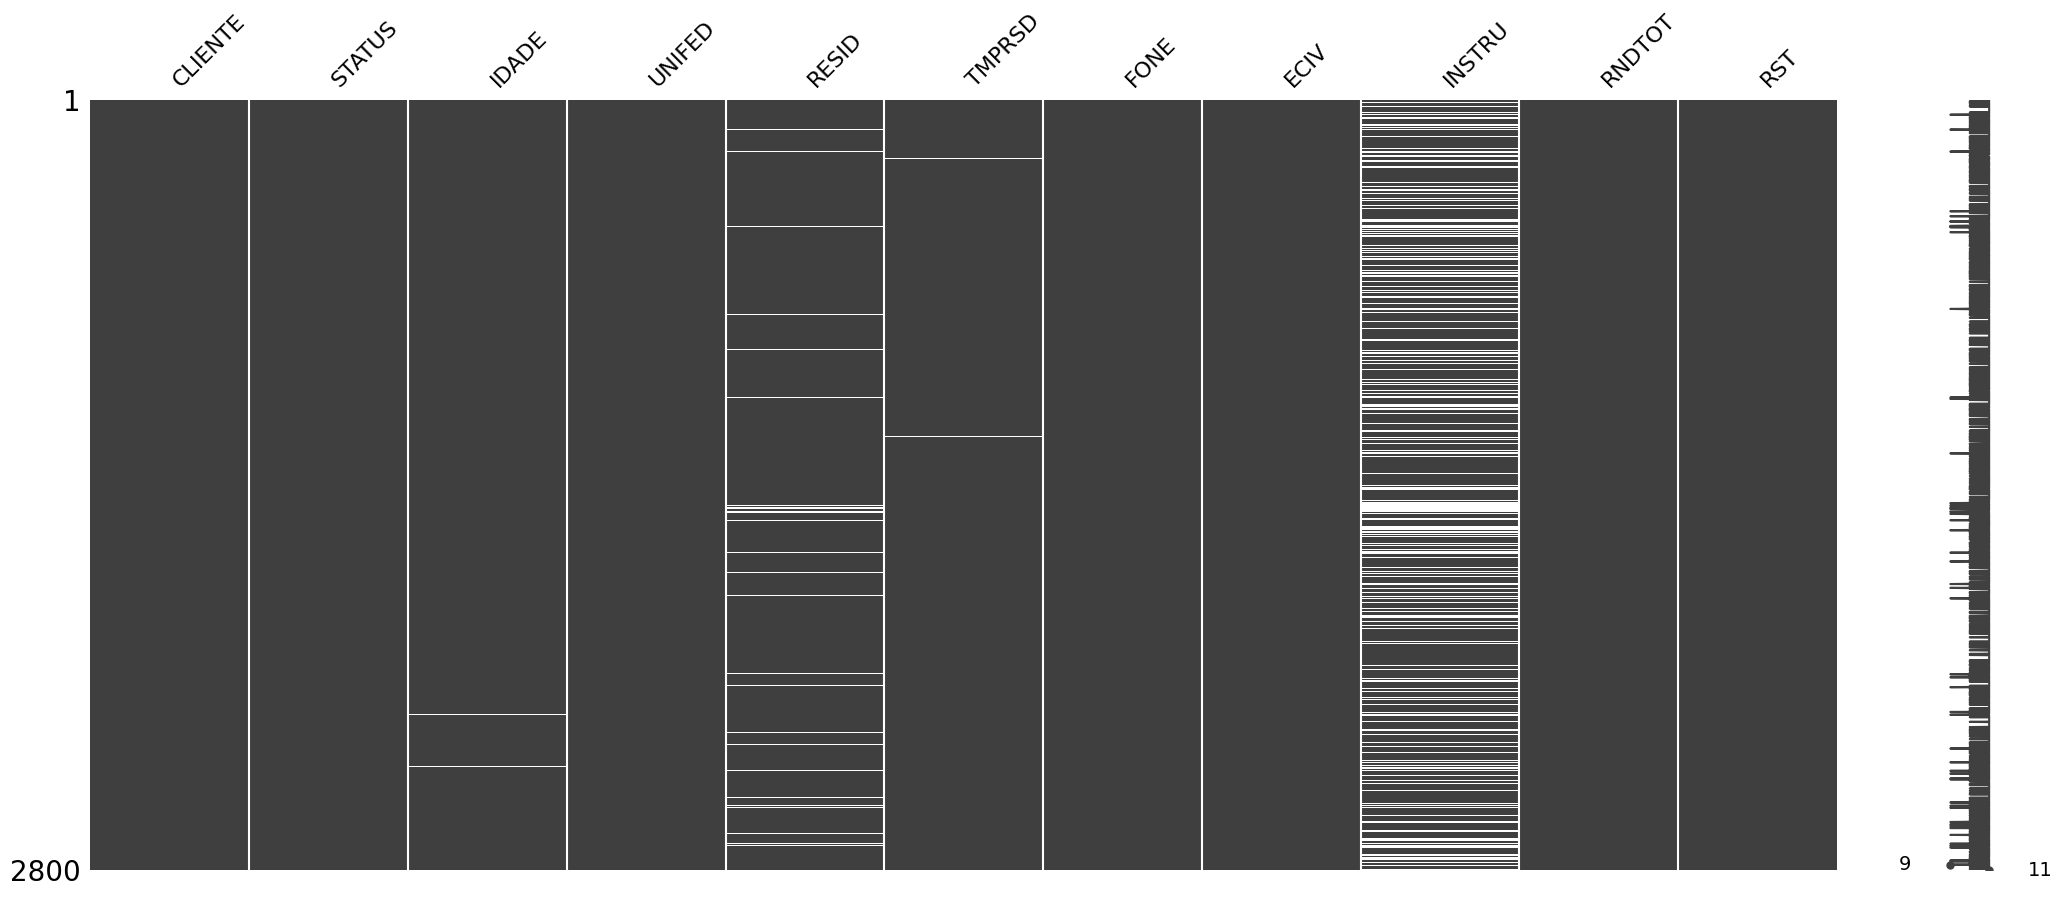

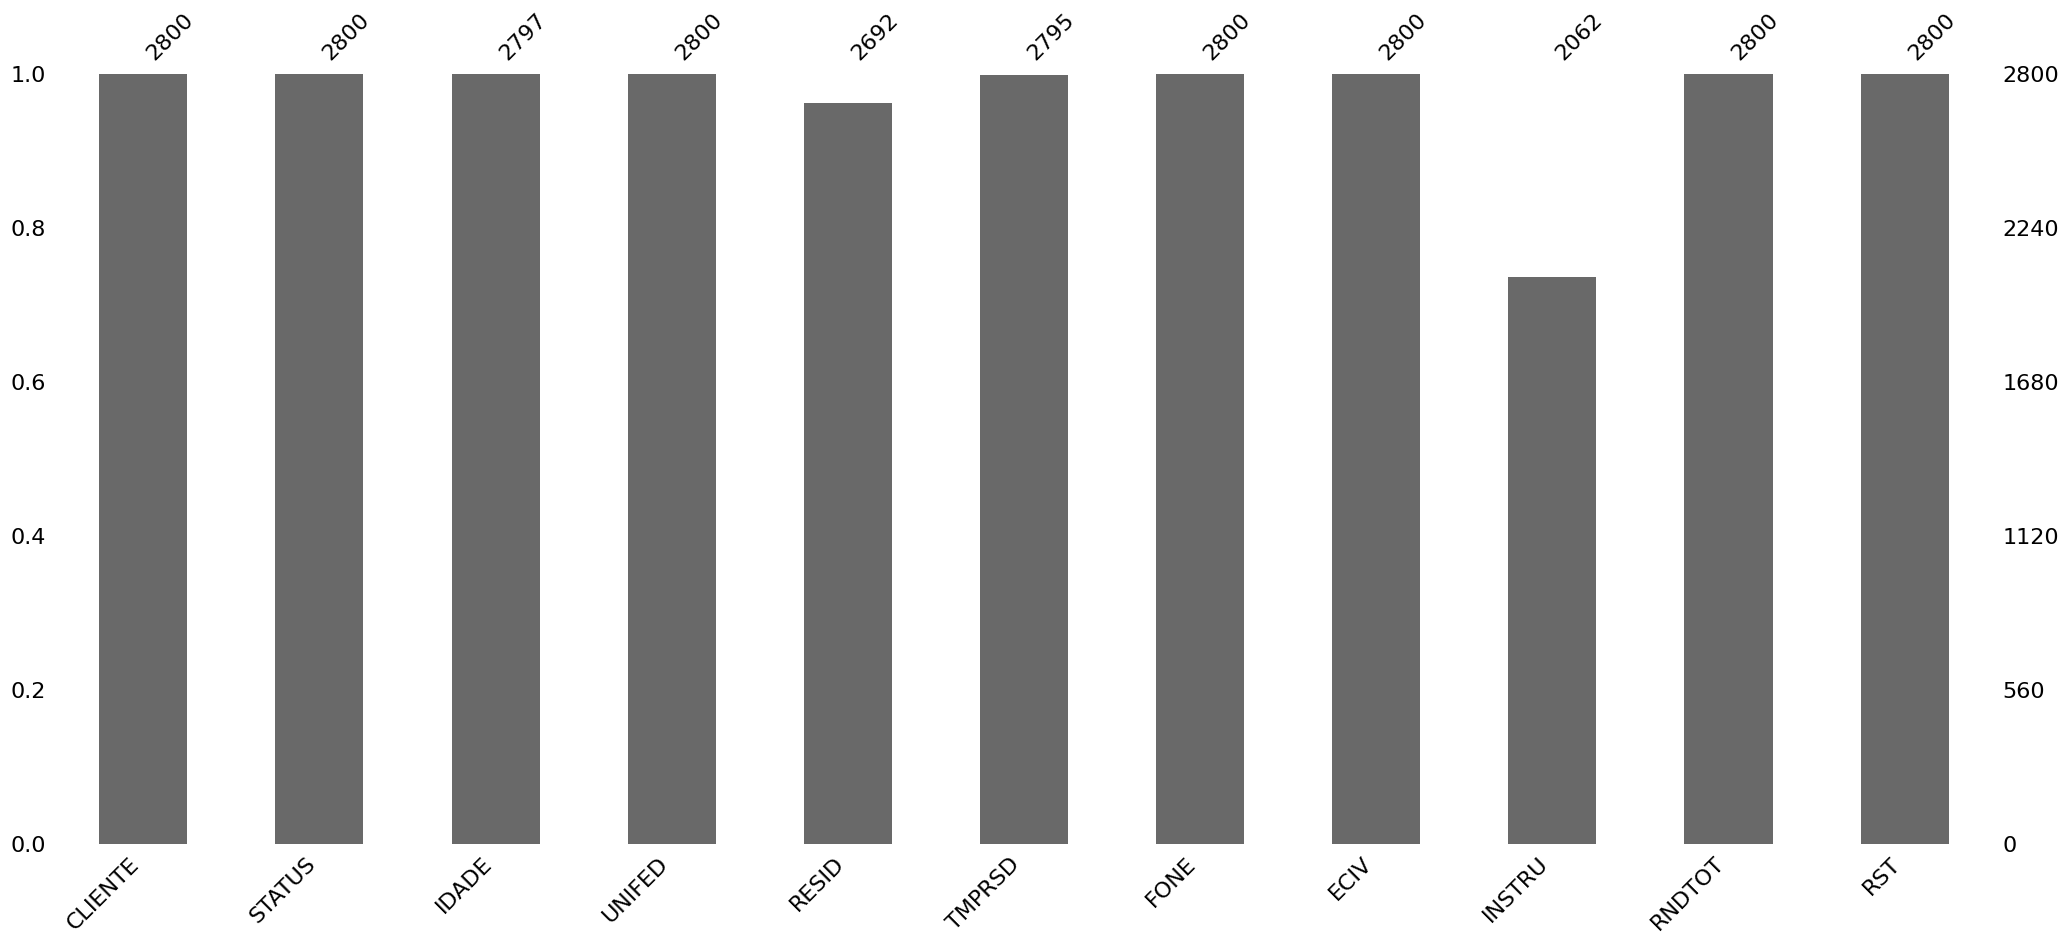

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 38.51it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


Tabela de Frequências da variável RESID:

Verificando valores ausentes após a imputação:
TMPRSD    0
IDADE     0
RNDTOT    0
dtype: int64

Primeiras linhas do DataFrame após a imputação:
    CLIENTE STATUS  IDADE UNIFED RESID  TMPRSD  FONE ECIV INSTRU  RNDTOT  RST
0  CLI_0001    mau   44.0     MG  PROP     5.0     1  CAS    SEC  6040.0  sim
1  CLI_0002    bom   46.0     MG  ALUG    12.0     1  CAS    SUP  6986.0  sim
2  CLI_0003    bom   56.0     MG  PROP    12.0     1  CAS    SUP  8797.0  sim
3  CLI_0004    bom   31.0     RJ  ALUG     4.0     1  CAS    SEC  4968.0  sim
4  CLI_0005    bom   46.0     RJ  PROP     8.0     1  CAS    NaN  7430.0  sim


In [1]:
# Código 2.4 - Missing Values

import missingno as msno
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
df = pd.read_excel('/content/sample_data/dirtyshop.xlsx')

# Visualização dos missing values por variável
msno.matrix(df)
plt.show()
# gráfico de barras com a contagem de missings por variável
msno.bar(df)
plt.show()
#heatmap
msno.heatmap(df)

# Gera um arquivo HTML com diagnóstico completo de missing, tipos de variável, outliers, etc.
!pip install ydata-profiling
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Análise Completa de Missing Values")
profile.to_file("relatorio_dirtyshop.html")

# Substitui os missing values na coluna 'RESID' por "MV"
df['RESID'] = df['RESID'].fillna('MV')

# Cria a tabela de frequências para a coluna 'RESID' (agora com "MV")
frequency_table_resid = df['RESID'].value_counts(dropna=False) # dropna=False inclui a contagem de "MV"

print("\nTabela de Frequências da variável RESID:")
frequency_table_resid


# Seleciona as colunas para imputação
cols_to_impute = ['TMPRSD', 'IDADE', 'RNDTOT']

# Cria uma cópia do DataFrame para não modificar o original diretamente
df_imputed = df.copy()

# Inicializa o IterativeImputer
# Usamos o n_nearest_features para limitar o número de variáveis usadas
# para prever cada valor ausente. Isso pode acelerar o processo.
# random_state para reprodutibilidade
imputer = IterativeImputer(max_iter=10, random_state=0, n_nearest_features=3)

# Aplica a imputação nas colunas selecionadas
# A saída do imputer é um array numpy, então precisamos convertê-lo de volta para DataFrame
df_imputed[cols_to_impute] = imputer.fit_transform(df_imputed[cols_to_impute])

# Opcional: Verifica se ainda há valores ausentes nas colunas imputadas
print("\nVerificando valores ausentes após a imputação:")
print(df_imputed[cols_to_impute].isnull().sum())

# Opcional: Exibe as primeiras linhas do DataFrame com os valores imputados
print("\nPrimeiras linhas do DataFrame após a imputação:")
print(df_imputed.head())

In [ ]:
# Código 2.5.1 e 2.5.2: transformação de variáveis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import boxcox



# Adiciona 1 à variável TMPRSD para lidar com valores iguais ou menores que zero,
# pois a transformação de Box-Cox  exige valores positivos.
#vamos usar o banco de dados imputado em (2.4) para que não haja valores missing da variável TMPRSD
df_imputed['TMPRSD_plus_1'] = df_imputed['TMPRSD'] + 1

# Aplica a transformação de Box-Cox na variável 'TMPRSD_plus_1'
# A função boxcox retorna a variável transformada e o parâmetro lambda ótimo
df_imputed['TMPRSD_boxcox'], fitted_lambda = boxcox(df_imputed['TMPRSD_plus_1'])

print(f"\nParâmetro Lambda ótimo para TMPRSD: {fitted_lambda}")

# Exibe as primeiras linhas do DataFrame com a nova variável transformada
print("\nPrimeiras linhas do DataFrame com TMPRSD transformada (Box-Cox):")
print(df_imputed[['TMPRSD', 'TMPRSD_plus_1', 'TMPRSD_boxcox']].head())

# Opcional: Visualiza a distribuição da variável transformada
plt.figure(figsize=(12, 6))
sns.histplot(df_imputed['TMPRSD_boxcox'], kde=True)
plt.xlabel('Tempo de Residência Transformado (Box-Cox)')
plt.ylabel('Frequência')
plt.title('Histograma de Tempo de Residência Transformado (Box-Cox)')
plt.show()

# Opcional: Visualiza o box-plot da variável transformada
plt.figure(figsize=(12, 6))
sns.boxplot(x=df_imputed['TMPRSD_boxcox'])
plt.xlabel('Tempo de Residência Transformado (Box-Cox)')
plt.title('Box-plot de Tempo de Residência Transformado (Box-Cox)')
plt.show()

# Crie as faixas para a variável RNDTOT
df_imputed['RNDTOT_faixa'], bins = pd.cut(df_imputed['RNDTOT'], bins=4, labels=False, retbins=True)

# Mostre os limites das faixas
print("\nLimites das faixas para RNDTOT:")
print(bins)

# Mostre a contagem de valores em cada faixa
print("\nContagem de valores em cada faixa de RNDTOT:")
print(df_imputed['RNDTOT_faixa'].value_counts().sort_index())


# Cria uma nova variável categórica dividindo RNDTOT em quartis
# labels=False cria rótulos numéricos de 0 a 3 para cada quartil
df_imputed['RNDTOT_quartil'], bins = pd.qcut(df_imputed['RNDTOT'], q=4, labels=False, retbins=True, duplicates='drop')

# limites (pontos de corte) usados para definir os quartis
# O `bins` retornado pelo qcut são os valores nos limites de cada quartil
print("\nLimites dos quartis para RNDTOT:")
print(bins)

# Opcional:  contagem de valores em cada quartil
print("\nContagem de valores em cada quartil de RNDTOT:")
print(df_imputed['RNDTOT_quartil'].value_counts().sort_index())

# Opcional:  primeiras linhas do DataFrame com a nova variável de quartil
print("\nPrimeiras linhas do DataFrame com a variável RNDTOT_quartil:")
print(df_imputed[['RNDTOT', 'RNDTOT_quartil']].head())

# Para ver as faixas de RNDTOT correspondentes a cada quartil numérico:
print("\nIntervalos de RNDTOT para cada quartil numérico:")
# Usamos cut com os mesmos bins para obter os intervalos textuais
intervals = pd.cut(df_imputed['RNDTOT'], bins=bins, labels=False, include_lowest=True, duplicates='drop')
# Mapeamos os rótulos numéricos dos quartis para os intervalos textuais
quartil_mapping = {i: interval for i, interval in enumerate(pd.cut(df_imputed['RNDTOT'], bins=bins, include_lowest=True, duplicates='drop').unique().sort_values())}
quartil_mapping

# Criamos a nova variável categórica 'RNDTOT_categoria'
def categorizar_renda(rndtot):
    if rndtot <= 4000:
        return 'baixa'
    elif 4001 <= rndtot <= 8000:
        return 'média'
    else:
        return 'alta'

df_imputed['RNDTOT_categoria'] = df_imputed['RNDTOT'].apply(categorizar_renda)

# Exibimos as primeiras linhas com a nova variável
print("\nPrimeiras linhas do DataFrame com a variável RNDTOT_categoria:")
print(df_imputed[['RNDTOT', 'RNDTOT_categoria']].head())

# Exibimos a contagem de valores em cada categoria para verificar a distribuição
print("\nContagem de valores em cada categoria de RNDTOT:")
print(df_imputed['RNDTOT_categoria'].value_counts())

In [3]:
# Código 2.5.3: Mean Encoding
import numpy as np
import pandas as pd
df = pd.read_excel('/content/sample_data/dirtyshop.xlsx')

# 1. Criar variável dummy para o target (STATUS): 1 = bom, 0 = mau
df['STATUSdummy'] = np.where(df['STATUS'] == 'bom', 1, 0)

# 2. Substituir missing values de INSTRU por um label, por exemplo "MV"
df['INSTRU'] = df['INSTRU'].astype(str).fillna('MV')

# 3. Aplicar o Mean Encoding (média de STATUSdummy por INSTRU)
mean_encoding = df.groupby('INSTRU')['STATUSdummy'].mean()

# 4. Criar nova coluna com o encoding
df['INSTRUencode'] = df['INSTRU'].map(mean_encoding)

freq_table = df['INSTRUencode'].round(2).value_counts().sort_index()

print(freq_table)

INSTRUencode
0.58     140
0.69     738
0.70    1252
0.72     670
Name: count, dtype: int64


In [4]:
#Código 2.6 - Componentes principais
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

#lê o arquivo com avaliação de professores
AVALIACOES = pd.read_excel('/content/sample_data/AVALIACOES.xlsx')
print(AVALIACOES.head())

# calcula a matriz de correlação entre AV1, AV2,AV3,AV4,AV5,AV6,AGLOB. Mostra resultado com 2 casas decimais
correlation_matrix = AVALIACOES[['AV1', 'AV2', 'AV3', 'AV4', 'AV5', 'AV6', 'AGLOB']].corr()
print("\nMatriz de Correlação:")
print(correlation_matrix.round(2))

# Análise de componentes princiapis entre as variáveis AV3 e AV6

# Seleciona as variáveis para a PCA
variables_pca = AVALIACOES[['AV3', 'AV6']].dropna() # Remove linhas com valores ausentes se houver

# Padroniza as variáveis (média 0, desvio padrão 1)
scaler = StandardScaler()
variables_pca_scaled = scaler.fit_transform(variables_pca)

# Realiza a Análise de Componentes Principais
# n_components=None calcula todos os componentes possíveis (igual ao número de variáveis)
pca = PCA(n_components=None)
pca.fit(variables_pca_scaled)

# Mostra o desvio-padrão de cada componente
# O desvio-padrão é a raiz quadrada dos autovalores
print("\nDesvio Padrão de cada Componente:")
print(np.sqrt(pca.explained_variance_))

# Mostra a proporção da variância explicada por cada componente
print("\nProporção da Variância Explicada por cada Componente:")
print(pca.explained_variance_ratio_)

# Mostra a proporção acumulada da variância explicada
print("\nProporção Acumulada da Variância Explicada:")
print(np.cumsum(pca.explained_variance_ratio_))

# Opcional: Mostra os loadings (pesos das variáveis em cada componente)
print("\nLoadings (Pesos das variáveis nos Componentes):")
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=variables_pca.columns)
loadings

#  análise de componentes principais para as variáveis AV1,AV2,AV3,AV4,AV5, AV6,AVGLOB .

# Seleciona as variáveis para a PCA
variables_pca_all = AVALIACOES[['AV1','AV2','AV3','AV4','AV5', 'AV6','AGLOB']].dropna() # Remove linhas com valores ausentes se houver

# Padroniza as variáveis (média 0, desvio padrão 1)
scaler_all = StandardScaler()
variables_pca_all_scaled = scaler_all.fit_transform(variables_pca_all)

# Realiza a Análise de Componentes Principais
# n_components=2 para obter os dois primeiros componentes
pca_all = PCA(n_components=2)
pca_all.fit(variables_pca_all_scaled)

# Mostra os loadings dos dois primeiros componentes principais
print("\nLoadings (Pesos das variáveis nos 2 Primeiros Componentes):")
loadings_all = pd.DataFrame(pca_all.components_.T, columns=['PC1', 'PC2'], index=variables_pca_all.columns)
print(loadings_all.round(4)) # Formata com 4 casas decimais

# Transforma os dados originais para obter o valor das componentes para cada indivíduo
pca_scores = pca_all.transform(variables_pca_all_scaled)

# Cria um DataFrame com os scores dos componentes
pca_scores_df = pd.DataFrame(pca_scores, columns=['PC1', 'PC2'], index=variables_pca_all.index)

# Junta os scores dos componentes com as variáveis originais
results_pca = pd.concat([variables_pca_all, pca_scores_df], axis=1)

# Mostra o valor das componentes para os 5 primeiros indivíduos, assim como as variáveis originais
print("\nVariáveis Originais e Scores dos 2 Primeiros Componentes para os 5 Primeiros Indivíduos:")
print(results_pca.head().round(4)) # Formata com 4 casas decimais


  PROFESSOR  AV1  AV2   AV3  AV4  AV5  AV6  AGLOB
0        P1  6.4  5.9   6.9  6.9    5  8.2    5.9
1        P2  8.3  6.1   7.6  9.4    3  8.7    7.0
2        P3  8.0  4.9   4.3  4.0    5  6.2    3.3
3        P4  8.7  4.2  10.0  2.4    4  8.5    8.4
4        P5  4.8  1.0   5.8  6.3    4  7.5    3.8

Matriz de Correlação:
        AV1   AV2   AV3   AV4   AV5   AV6  AGLOB
AV1    1.00  0.05  0.55  0.60 -0.13  0.42   0.54
AV2    0.05  1.00  0.22  0.30 -0.06  0.33   0.47
AV3    0.55  0.22  1.00  0.43 -0.18  0.81   0.90
AV4    0.60  0.30  0.43  1.00  0.02  0.48   0.51
AV5   -0.13 -0.06 -0.18  0.02  1.00 -0.18  -0.21
AV6    0.42  0.33  0.81  0.48 -0.18  1.00   0.88
AGLOB  0.54  0.47  0.90  0.51 -0.21  0.88   1.00

Desvio Padrão de cada Componente:
[1.36849924 0.44291688]

Proporção da Variância Explicada por cada Componente:
[0.90518191 0.09481809]

Proporção Acumulada da Variância Explicada:
[0.90518191 1.        ]

Loadings (Pesos das variáveis nos Componentes):

Loadings (Pesos das variávei

In [ ]:
#Código 2.8 - Imbalance

#lê o arquivo com dados desbalanceados
import pandas as pd
from imblearn.over_sampling import SMOTE
BUX_IMBALANCE = pd.read_excel('/content/sample_data/BUX_IMBALANCE.xlsx')

# Cria a tabela de frequências para a coluna 'STATUS'
frequency_table_status = BUX_IMBALANCE['STATUS'].value_counts()

print("\nTabela de Frequências da variável STATUS:")
print(frequency_table_status)

# Separando preditores e variável resposta
X = BUX_IMBALANCE.drop(columns='STATUS')
y = BUX_IMBALANCE['STATUS']

# Identifica variáveis categóricas
categorical_cols = X.select_dtypes(include=['object', 'category']).columns

# Cria variáveis dummy para as variáveis categóricas
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Aplicando SMOTE apenas para a classe minoritária
smote = SMOTE(sampling_strategy={'MAU': 2400, 'BOM': 2400}, random_state=1)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Recombinando o X e y em um único DataFrame
data_rose = pd.concat([X_resampled, y_resampled], axis=1)

# Verificando o novo balanceamento
print(data_rose['STATUS'].value_counts())

In [5]:
# Compara as médias das variáveis numéricas antes e depois do balanceamento
# Seleciona apenas as colunas numéricas
import numpy as np
numerical_cols = BUX_IMBALANCE.select_dtypes(include=np.number).columns

print("Médias das variáveis numéricas antes do balanceamento (agrupadas por STATUS):")
print(BUX_IMBALANCE.groupby('STATUS')[numerical_cols].mean())

print("\nMédias das variáveis numéricas depois do balanceamento (SMOTE, agrupadas por STATUS):")
print(data_rose.groupby('STATUS')[numerical_cols].mean())

Médias das variáveis numéricas antes do balanceamento (agrupadas por STATUS):
        IDADE
STATUS       
BOM     42.72
MAU     39.83

Médias das variáveis numéricas depois do balanceamento (SMOTE, agrupadas por STATUS):
          IDADE
STATUS         
BOM     42.7200
MAU     39.7575
